# Data Understanding

In [1]:
pip install pandoc

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import mysql.connector
conn = mysql.connector.connect(
    host = 'localhost',
    user = 'root',
    password = '123@@abcD',
    database = 'retail-project'
)
with open('joined_table.sql','r') as file:
    query = file.read()
df = pd.read_sql(query, conn)
df

/var/folders/y8/4rjnjsgj50qcw4k1myyp4j3r0000gn/T/ipykernel_2784/3049060918.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,transaction_id,date,product_id,store_id,customer_id,quantity,discount,returned,category,color,...,season,supplier,cost_price,list_price,store_name,region,store_size_m2,age,gender,city
0,T0001754,2023-01-05,P000025,S002,C016996,3,0.0,0,Dresses,Green,...,Spring,supplierb,44.01,186.69,Porto Center,Porto,728,69,Other,Porto
1,T0001745,2020-10-13,P000056,S005,C006388,3,0.2,0,Dresses,Black,...,Fall,supplierc,71.00,161.27,Coimbra Boutique,Coimbra,238,31,Female,Porto
2,T0001634,2024-06-24,P000098,S001,C005947,4,0.1,0,Shoes,Yellow,...,Summer,suppliera,24.05,87.38,Lisbon Flagship,Lisbon,179,47,Male,Porto
3,T0000537,2024-12-13,P000199,S002,C004963,3,0.0,0,Accessories,Green,...,Winter,suppliera,72.15,120.60,Porto Center,Porto,728,66,Female,Braga
4,T0000764,2024-10-28,P000206,S004,C009283,4,0.0,0,Tops,Blue,...,Spring,supplierb,38.43,147.24,Online,Online,950,67,Male,Braga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47764,T0034585,2021-05-05,P049392,S001,C021196,3,0.0,0,Tops,Blue,...,Summer,supplierd,72.21,11.59,Lisbon Flagship,Lisbon,179,33,Male,Faro
47765,T0033403,2022-09-28,P049392,S002,C015122,4,0.3,0,Tops,Blue,...,Summer,supplierd,72.21,11.59,Porto Center,Porto,728,22,Male,Braga
47766,T0024275,2021-02-24,P049392,S005,C014211,4,0.0,0,Tops,Blue,...,Summer,supplierd,72.21,11.59,Coimbra Boutique,Coimbra,238,38,Male,Faro
47767,T0046834,2022-06-07,P049488,S001,C017886,1,0.2,0,Bottoms,Blue,...,Fall,supplierd,73.97,172.17,Lisbon Flagship,Lisbon,179,61,Female,Porto


In [2]:
df.describe()

,quantity,returned,cost_price,list_price,store_size_m2,age
count,47769.000000,47769.000000,47769.000000,47769.000000,47769.000000,47769.000000
mean,2.506270,0.099081,42.507168,105.268601,484.601436,42.515899
std,1.118749,0.298774,21.722008,54.782448,300.512784,15.593957
min,1.000000,0.000000,5.000000,10.000000,179.000000,16.000000
25%,2.000000,0.000000,23.780000,58.260000,238.000000,29.000000
50%,3.000000,0.000000,42.410000,105.440000,336.000000,43.000000
75%,4.000000,0.000000,61.390000,152.600000,728.000000,56.000000
max,4.000000,1.000000,80.000000,199.990000,950.000000,69.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47769 entries, 0 to 47768
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  47769 non-null  object 
 1   date            47769 non-null  object 
 2   product_id      47769 non-null  object 
 3   store_id        47769 non-null  object 
 4   customer_id     47769 non-null  object 
 5   quantity        47769 non-null  int64  
 6   discount        47769 non-null  object 
 7   returned        47769 non-null  int64  
 8   category        47326 non-null  object 
 9   color           46860 non-null  object 
 10  size            47769 non-null  object 
 11  season          47769 non-null  object 
 12  supplier        47769 non-null  object 
 13  cost_price      47769 non-null  float64
 14  list_price      47769 non-null  float64
 15  store_name      47769 non-null  object 
 16  region          47769 non-null  object 
 17  store_size_m2   47769 non-null 

In [4]:
# Convert to numeric
df['discount'] = pd.to_numeric(df['discount'],errors='coerce')
df['discount']=df['discount'].fillna(0)

In [5]:
# Convert to numeric
df['quantity'] = pd.to_numeric(df['quantity'],errors='coerce')
df['list_price']=pd.to_numeric(df['list_price'],errors='coerce')
df['cost_price']=pd.to_numeric(df['cost_price'],errors='coerce')

In [6]:
df['date'] = pd.to_datetime(df['date'])
df['date'].dtype

dtype('<M8[ns]')

In [7]:
# df[df['category'].isnull()]['revenue'].sum() / df['revenue'].sum()
# since impact of null category rows is less than 1% in revenue, we can label them as unknown
df['category'] = df['category'].fillna('Unknown')
df['category'].isna().sum()

0

In [8]:
# df[df['color'].isnull()]['revenue'].sum() / df['revenue'].sum()
# since impact of null color rows is less than 1% in revenue, we can label them as unknown
df['color'] = df['color'].fillna('Unknown')
df['color'].isna().sum()

0

In [9]:
df.loc[df['gender']=='???','gender']='Unknown'
df['gender'].value_counts()

gender
Male       16043
Other      15721
Female     15426
Unknown      579
Name: count, dtype: int64

# Revenue and Profit Analysis

In [10]:
df['cost_price'].apply(type).value_counts()

cost_price
<class 'float'>    47769
Name: count, dtype: int64

In [11]:
df['revenue'] = df['quantity'] * df['list_price'] * (1 - df['discount'])
df['profit'] = (df['list_price'] - df['cost_price']) * df['quantity']

### Total revenue and total profit

In [12]:
print('Total Revenue = ',df['revenue'].sum())
print('Total Profit = ',df['profit'].sum())

Total Revenue =  11902231.542
Total Profit =  7506432.380000001


### Revenue trend by month

In [13]:
df['date_by_month'] = df['date'].dt.to_period(freq='M')
df['date_by_month']
df['date_by_month'].unique()

<PeriodArray>
['2023-01', '2020-10', '2024-06', '2024-12', '2024-10', '2023-10', '2024-08',
 '2022-03', '2021-02', '2023-06', '2020-11', '2021-03', '2024-07', '2022-09',
 '2022-10', '2023-04', '2023-05', '2021-07', '2024-02', '2020-12', '2023-03',
 '2024-11', '2024-01', '2020-04', '2022-04', '2023-08', '2020-05', '2021-04',
 '2022-01', '2022-07', '2021-01', '2020-01', '2023-11', '2020-02', '2022-08',
 '2024-03', '2023-07', '2021-12', '2020-06', '2022-02', '2022-06', '2022-05',
 '2024-05', '2024-04', '2021-11', '2021-05', '2021-08', '2021-06', '2020-07',
 '2024-09', '2023-09', '2022-12', '2020-08', '2021-09', '2022-11', '2020-03',
 '2021-10', '2020-09', '2023-02', '2023-12']
Length: 60, dtype: period[M]

In [46]:
df.to_csv('dataframe.csv')

In [14]:
monthly_rev=df.groupby('date_by_month')['revenue'].sum().reset_index(name='monthly_revenue')
monthly_rev['date_by_month'].dtype

period[M]

In [15]:
monthly_rev['date_by_month'] = monthly_rev['date_by_month'].dt.to_timestamp()
monthly_rev['date_by_month'].dtype

dtype('<M8[ns]')

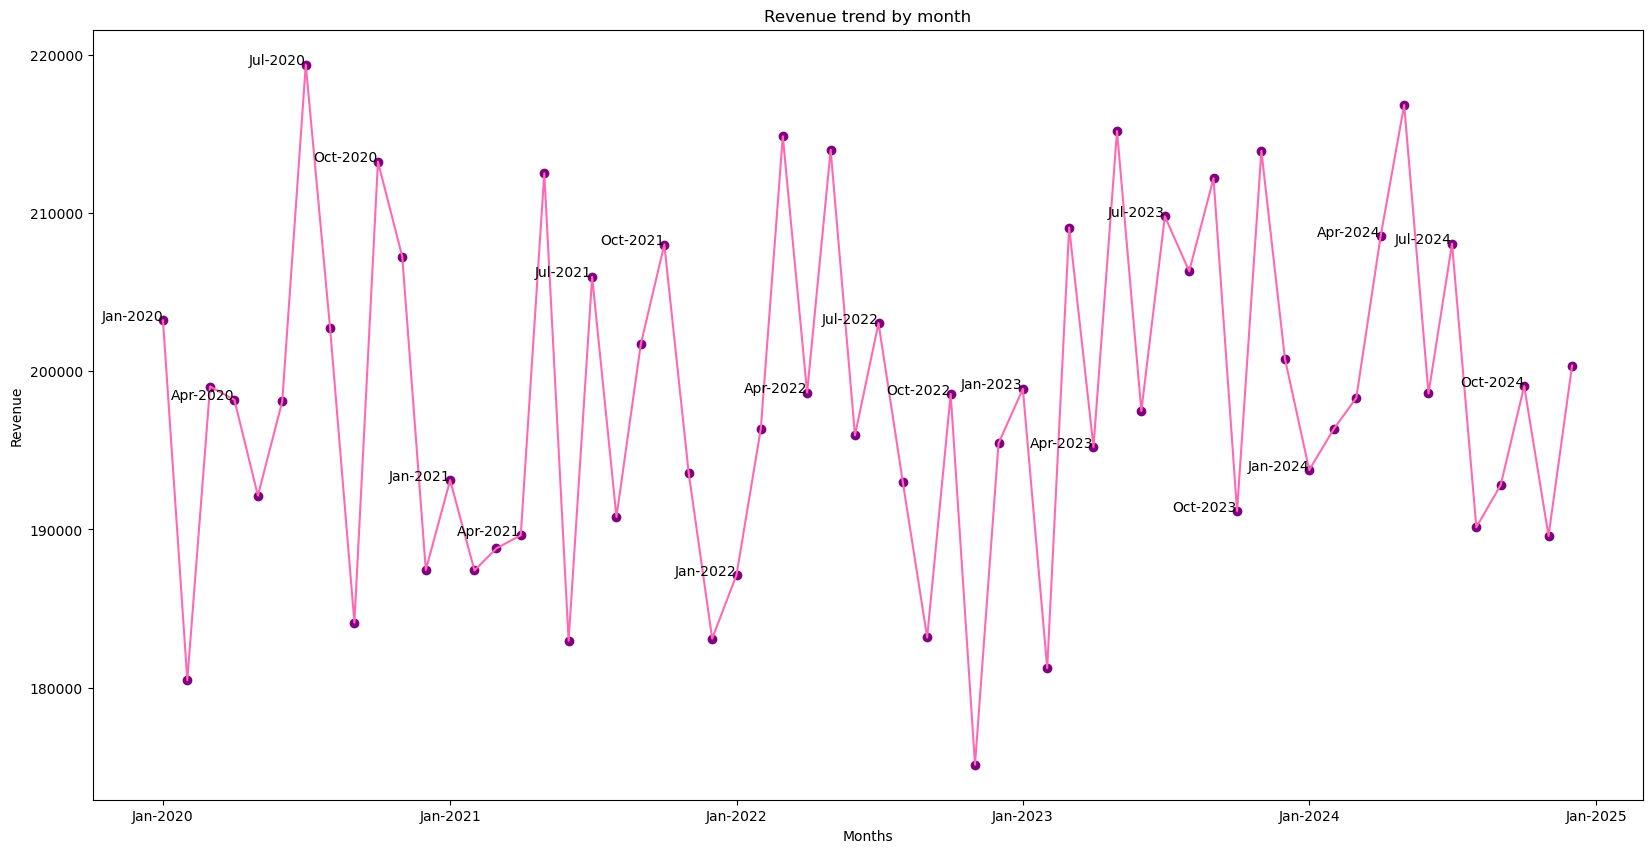

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
figure, axes = plt.subplots(figsize=(20, 10))
plt.scatter(monthly_rev['date_by_month'], monthly_rev['monthly_revenue'],color='purple')
axes.plot(monthly_rev['date_by_month'], monthly_rev['monthly_revenue'],color='hotpink')
#plt.xticks(rotation=90)
axes.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
# axes.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xlabel('Months')
plt.ylabel('Revenue')
plt.title('Revenue trend by month')
for i, (x, y) in enumerate(zip(monthly_rev['date_by_month'],monthly_rev['monthly_revenue'])): 
    if i % 3 == 0:   # every 3rd month
        axes.text(x, y, x.strftime('%b-%Y'),fontsize=10,ha='right')
plt.show()

1. Clear Seasonality Pattern
2021, 2022, 2023, 2024 show peak revenue around May–July.
2020 peak shifted to July (likely anomaly year).
Indicates strong mid-year seasonal demand.
This suggests possible:
Summer collection boost
Mid-year promotions
Seasonal buying cycle

2. No Strong Upward CAGR
Start and end years appear similar revenue range (~200k–220k band).
So:
Business is stable
Not aggressively growing

# Trend Insights

## Seasonal Category Performance

In [17]:
season_cat = (
    df.groupby(['season','category'])['revenue']
      .mean()
      .sort_values(ascending=False)  
      .reset_index()
      
)
season_cat.head()

,season,category,revenue
0,Winter,Dresses,256.475504
1,Summer,Shoes,255.726309
2,Summer,Tops,253.836180
3,Summer,Accessories,253.250144
4,Fall,Dresses,252.123962


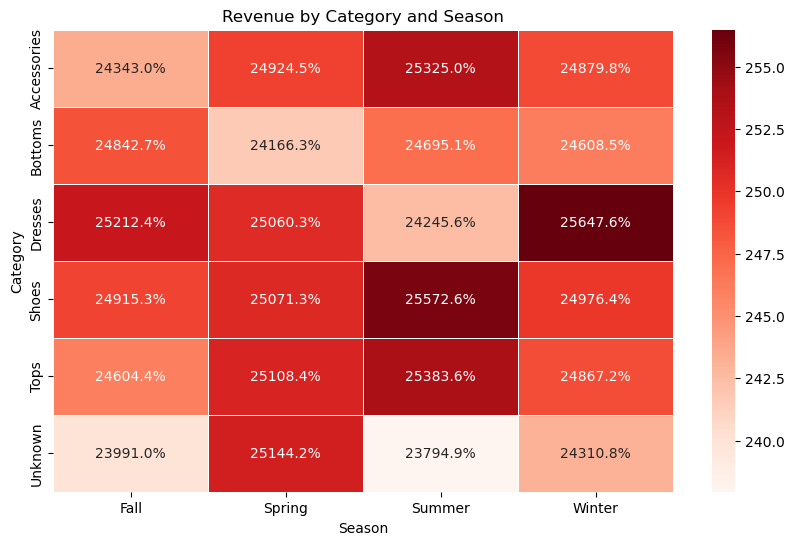

In [18]:
import seaborn as sns
# Pivot for heatmap
heatmap_data = season_cat.pivot(index='category', columns='season', values='revenue')

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,       # show numbers
    fmt=".1%",        # format as percentage
    cmap="Reds",      # color intensity = higher return
    linewidths=0.5
)
plt.title("Revenue by Category and Season")
plt.ylabel("Category")
plt.xlabel("Season")
plt.show()

In [19]:
# ax= sns.barplot(data=season_cat, x='category', y='revenue', hue='season')
# sns.move_legend(ax,"upper left",bbox_to_anchor=(1,1))
# plt.title('Revenue by Category in each season')
# plt.xlabel('Category')
# plt.ylabel('Revenue')
# plt.show()

### Sales by season

In [20]:
season_sales = df.groupby('season').agg({'revenue':'sum','profit':'sum'}).sort_values(by='revenue',ascending=False).reset_index()
season_sales

,season,revenue,profit
0,Winter,2996318.082,1887317.64
1,Summer,2995715.450,1902307.63
2,Spring,2963758.460,1868917.53
3,Fall,2946439.550,1847889.58


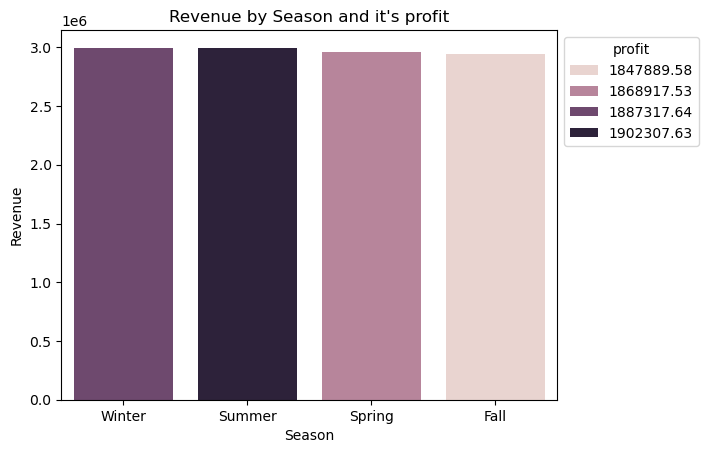

In [21]:
ax= sns.barplot(data=season_sales, x='season', y='revenue', hue='profit')
sns.move_legend(ax,"upper left",bbox_to_anchor=(1,1))
plt.title("Revenue by Season and it's profit")
plt.xlabel('Season')
plt.ylabel('Revenue')
plt.show()

Fashion & Seasonal Insights

1. Category-level seasonal performance:
Winter sees Dresses leading revenue, while Summer peaks for Shoes, Tops, and Accessories.
Fall and Spring show moderate performance across categories.
- Actionable insight: Use this to plan inventory, merchandising, and marketing campaigns for category-specific seasonal peaks.

2. Overall seasonal sales & profitability:
Winter has the highest total revenue, but Summer generates slightly higher profit, suggesting better pricing or margins.
Spring and Fall show nearly equal revenue and profit.
- Actionable insight: Adjust pricing and promotional strategies seasonally to maximize profit without sacrificing revenue.

3. Combined takeaway:
Winter: strong volume → push high-demand categories like Dresses.
Summer: strong margins → focus on Shoes, Tops, Accessories with optimized pricing.
This dual perspective allows data-driven decisions on stock, pricing, and seasonal campaigns.

### Top 5 categories by revenue

In [22]:
top_cat = df.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index(name='category_revenue')
# top_cat['category_revenue'].dtype

In [23]:
top_cat

,category,category_revenue
0,Accessories,2381480.253
1,Shoes,2380369.626
2,Dresses,2371651.401
3,Tops,2335487.099
4,Bottoms,2325265.976
5,Unknown,107977.187


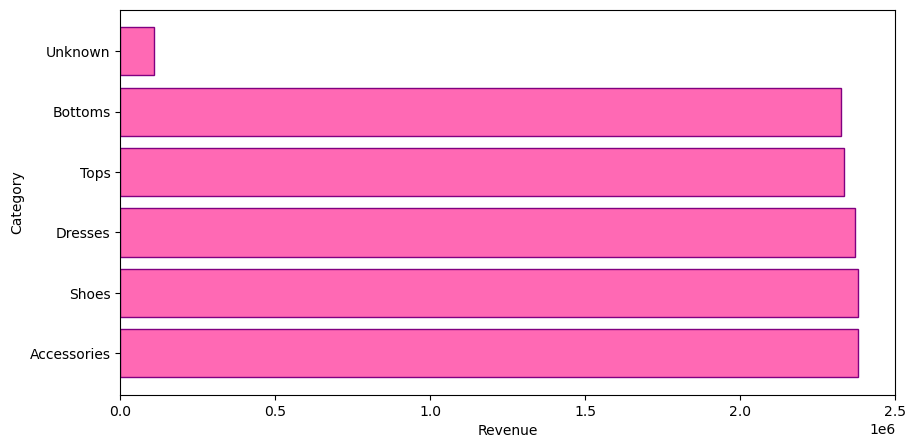

In [24]:
plt.figure(figsize=(10,5))
plt.barh(top_cat['category'], top_cat['category_revenue'],color='hotpink',edgecolor='purple')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.show()

### Top 5 categories by profit

In [25]:
top_cat_pro = df.groupby('category')['profit'].sum().sort_values(ascending=False).reset_index(name='profit')
# top_cat['category_revenue'].dtype
top_cat_pro

,category,profit
0,Dresses,1508733.37
1,Shoes,1499166.79
2,Accessories,1495731.50
3,Tops,1473545.36
4,Bottoms,1466801.53
5,Unknown,62453.83


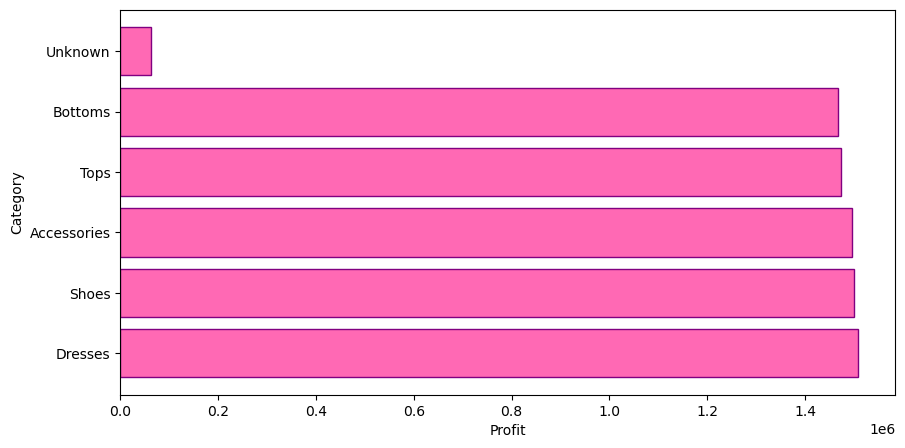

In [26]:
plt.figure(figsize=(10,5))
plt.barh(top_cat_pro['category'], top_cat_pro['profit'],color='hotpink',edgecolor='purple')
plt.xlabel('Profit')
plt.ylabel('Category')
plt.show()

### Top 10 products by revenue

In [27]:
top_prod = (
    df.groupby('product_id')
      .agg({
          'revenue': 'sum',
          'profit': 'sum',
          'category': 'first',
          'season':'first'
      })
      .sort_values(by='profit', ascending=False)
      .head(10)
      .reset_index()
)
top_prod

,product_id,revenue,profit,category,season
0,P012529,3330.300,3197.02,Bottoms,Spring
1,P039149,2788.024,2928.00,Tops,Summer
2,P025493,3209.444,2788.85,Tops,Summer
3,P022324,3488.800,2728.40,Accessories,Summer
4,P003362,2855.364,2650.65,Bottoms,Spring
5,P005856,2881.602,2577.60,Shoes,Winter
6,P014253,2335.568,2513.84,Accessories,Spring
7,P028671,2516.000,2477.02,Bottoms,Fall
8,P003285,2353.106,2417.61,Dresses,Fall
9,P029873,2806.958,2415.68,Shoes,Summer


1. No Single-Category Dominance
- Top 10 SKUs are distributed across:
    1. Bottoms (3)
    2. Tops (2)
    3. Dresses (2)
    4. Accessories (2)
    5. Shoes (1)
- This confirms:
Profitability is diversified at SKU level.
2. Bottoms Overrepresented at SKU Level
- Even though Bottoms were not the top category in total profit, they appear most frequently in top 10.
- This suggests:
Strong individual hero products
Possibly higher margin SKUs within Bottoms
Category total ≠ SKU strength concentration.
3. Revenue vs Profit Differences
- Some SKUs show:
Profit slightly higher relative to revenue pattern
Indicates margin variation across products.
- High-profit SKUs are concentrated in Spring–Summer seasons, indicating stronger margin realization during warmer collections compared to Winter.

# Store Performance

### Region by top revenue

In [28]:
region_rev = (
    df.groupby('region')
      .agg({
          'revenue': 'sum',
          'profit': 'sum',
          'store_name': 'first',
          'store_size_m2':'first'
      })
      .sort_values(by='revenue', ascending=False)
      .reset_index()
)
region_rev

,region,revenue,profit,store_name,store_size_m2
0,Algarve,2418159.025,1529947.03,Faro Outlet,336
1,Lisbon,2413181.997,1517896.28,Lisbon Flagship,179
2,Coimbra,2369401.989,1492263.41,Coimbra Boutique,238
3,Porto,2351611.755,1477858.59,Porto Center,728
4,Online,2349876.776,1488467.07,Online,950


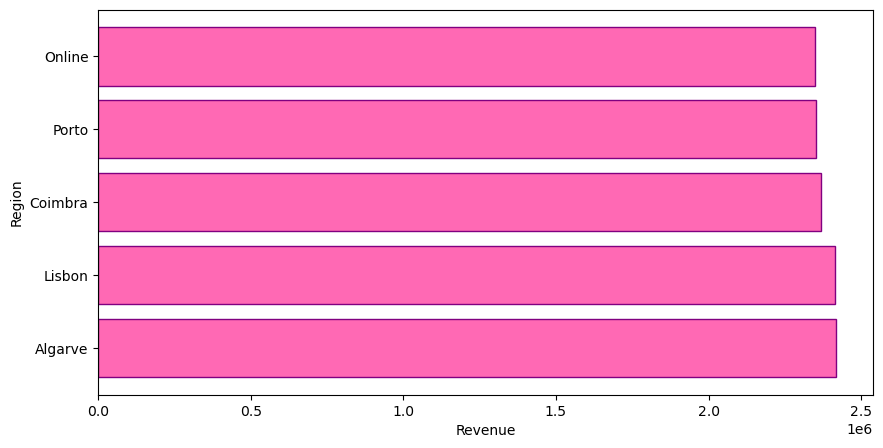

In [29]:
plt.figure(figsize=(10,5))
plt.barh(region_rev['region'],region_rev['revenue'],color='hotpink',edgecolor='purple')
plt.xlabel('Revenue')
plt.ylabel('Region')
plt.show()

### Does store size matter?

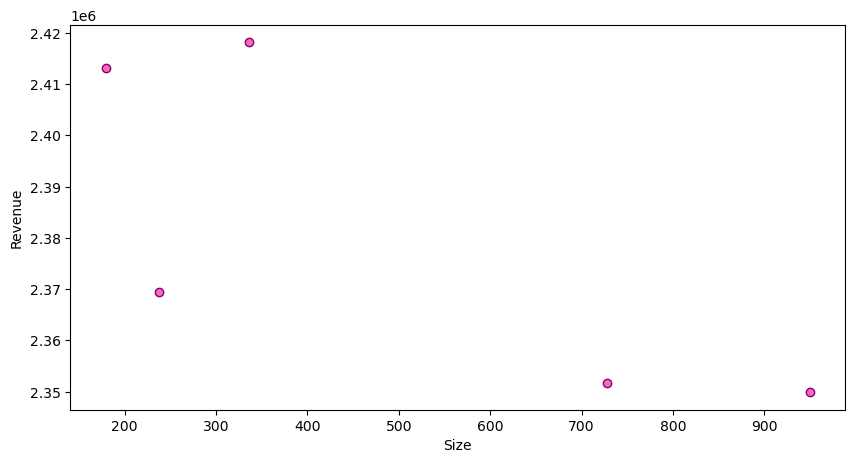

In [30]:
plt.figure(figsize=(10,5))
plt.scatter(region_rev['store_size_m2'],region_rev['revenue'],color='hotpink',edgecolor='purple')
plt.xlabel('Size')
plt.ylabel('Revenue')
plt.show()

### Revenue per square metre

In [31]:
region_rev['rev_per_m'] = region_rev['revenue']/region_rev['store_size_m2']
region_rev

,region,revenue,profit,store_name,store_size_m2,rev_per_m
0,Algarve,2418159.025,1529947.03,Faro Outlet,336,7196.901860
1,Lisbon,2413181.997,1517896.28,Lisbon Flagship,179,13481.463670
2,Coimbra,2369401.989,1492263.41,Coimbra Boutique,238,9955.470542
3,Porto,2351611.755,1477858.59,Porto Center,728,3230.235927
4,Online,2349876.776,1488467.07,Online,950,2473.554501


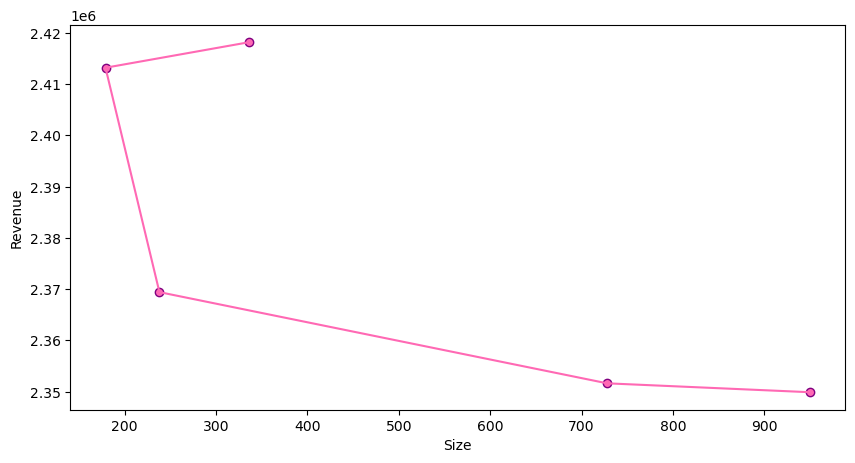

In [32]:
plt.figure(figsize=(10,5))
plt.scatter(region_rev['store_size_m2'],region_rev['revenue'],color='hotpink',edgecolor='purple')
plt.plot(region_rev['store_size_m2'],region_rev['revenue'],color='hotpink')
plt.xlabel('Size')
plt.ylabel('Revenue')
plt.show()

### Return rate by store

In [33]:
store_return = (
    df.groupby(['store_id','store_name'])['returned']
      .mean()
      .reset_index(name='return_rate')
      .sort_values(by='return_rate', ascending=False)
)
store_return

,store_id,store_name,return_rate
1,S002,Porto Center,0.104596
3,S004,Online,0.098743
4,S005,Coimbra Boutique,0.098641
2,S003,Faro Outlet,0.098550
0,S001,Lisbon Flagship,0.094950


Store & Region Performance — Final Insights
1. Regional Revenue Performance
Revenue across regions is very balanced (approx 2.35M–2.42M range).
Algarve slightly highest
Online and Porto slightly lower
No region dominates revenue
Insight:
Business performance is geographically diversified. No heavy dependency on a single region.
2. Store Size vs Revenue
Larger stores do not generate higher revenue.
Lisbon (179 m²) → among highest revenue
Online (950 m²) → among lowest revenue
Porto (728 m²) → lower than smaller stores
Insight:
There is no positive correlation between store size and revenue.
Size ≠ performance driver.
3. Revenue Efficiency (Revenue per m²)
Clear pattern:
Smaller stores generate higher revenue per square meter.
Lisbon (smallest store) is most efficient.
Efficiency decreases as store size increases.
Business Implication:
Prime, compact locations may outperform large-format stores.
Large stores may have underutilized space.
4. Return Rate by Store
Return rates are tightly clustered:
Highest: Porto (approx10.46%)
Lowest: Lisbon (approx9.49%)
Range difference ≈ 1%
Insight:
No major return problem at any store.
Operational quality appears consistent.
Most efficient store (Lisbon) also has lowest return rate.
This suggests stronger product-market fit or better customer satisfaction at high-efficiency stores.

### Strategic Summary
- Revenue is regionally balanced.
- Store size does not drive revenue.
- Smaller stores are more space-efficient.
- Return behavior is stable across regions.
- This completes Store & Region analysis with meaningful, defensible insights.

# Customer Insights

### Revenue by Gender

In [34]:
gender_rev = (
    df.groupby('gender')
      .agg({
          'revenue': 'sum',
          'profit': 'sum'
      })
      .sort_values(by='revenue', ascending=False)
      .reset_index()
)
gender_rev

,gender,revenue,profit
0,Male,3996735.084,2519094.50
1,Other,3931978.963,2484789.64
2,Female,3828124.568,2408364.20
3,Unknown,145392.927,94184.04


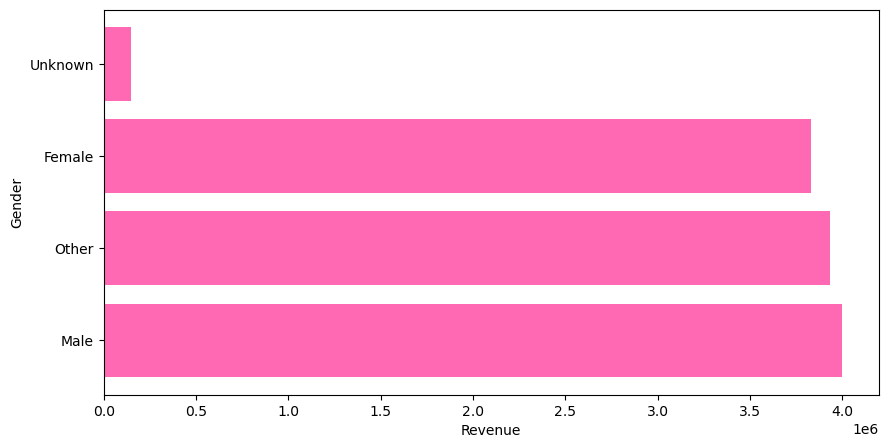

In [35]:
plt.figure(figsize=(10,5))
#plt.scatter(gender_rev['gender'],gender_rev['revenue'],color='hotpink',edgecolor='purple')
plt.barh(gender_rev['gender'],gender_rev['revenue'],color='hotpink')
plt.xlabel('Revenue')
plt.ylabel('Gender')
plt.show()

### Top 10 ages by spending

In [36]:
customer_rev = (
    df.groupby('age')
      .agg({
          'revenue': 'sum',
          'profit': 'sum'
      })
      .head(10)
      .sort_values(by='revenue', ascending=False)
      .reset_index()
)
customer_rev

,age,revenue,profit
0,20,242138.844,153797.37
1,23,227336.554,146630.87
2,17,223819.595,135171.91
3,16,223779.007,146551.51
4,19,218165.317,138091.10
5,21,209970.889,133230.91
6,25,209542.102,130839.67
7,22,208623.030,131513.05
8,18,205600.161,129006.50
9,24,190108.253,118050.56


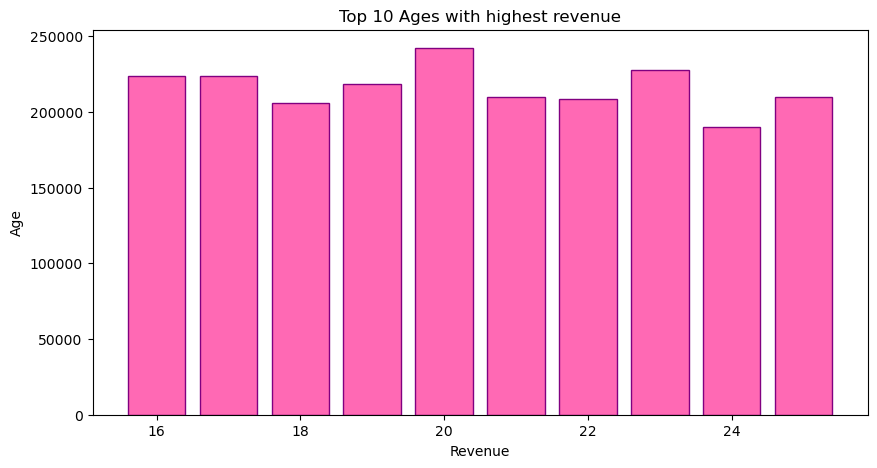

In [37]:
plt.figure(figsize=(10,5))
#plt.scatter(gender_rev['gender'],gender_rev['revenue'],color='hotpink',edgecolor='purple')
plt.bar(customer_rev['age'],customer_rev['revenue'],color='hotpink',edgecolor='purple')
plt.xlabel('Revenue')
plt.ylabel('Age')
plt.title('Top 10 Ages with highest revenue')
plt.show()

### Repeat customer rate

In [38]:
# Count transactions per customer
repeat_counts = df.groupby('customer_id')['transaction_id'].nunique()

# Flag repeat vs one-time
df['repeat_flag'] = df['customer_id'].map(lambda x: 'Repeat' if repeat_counts[x] > 1 else 'One-time')

# Aggregate revenue and profit by repeat_flag
repeat_summary = (
    df.groupby('repeat_flag')
      .agg({
          'revenue': 'sum',
          'profit': 'sum',
          'customer_id': 'nunique'  # number of customers
      })
      .sort_values('revenue',ascending=False)
      .rename(columns={'customer_id': 'num_customers'})
      .reset_index()
)
repeat_summary

,repeat_flag,revenue,profit,num_customers
0,Repeat,1.012491e+07,6378021.33,14116
1,One-time,1.777322e+06,1128411.05,7104


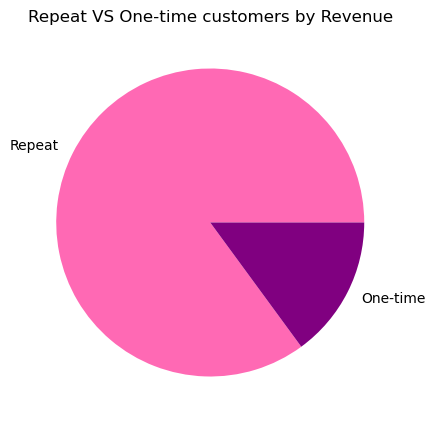

In [39]:
plt.figure(figsize=(5,5))
plt.pie(repeat_summary['revenue'],colors=['hotpink','purple'],labels=['Repeat', 'One-time'])
plt.title('Repeat VS One-time customers by Revenue')
plt.show()

1. Gender Insights
Revenue ranking: Male > Other > Female > Unknown
Difference among top three is marginal, but males slightly lead.
Unknown gender contributes negligible revenue, likely missing data.
2. Age Insights
Top 10 revenue-generating ages: 16–25, with peak at 20.
Indicates a young customer base; marketing campaigns should target youth.
3. Repeat Customer Insights
Repeat customers (14,116) generate ~10.1M revenue, vs one-time customers (7,104) generating ~1.78M.
Repeaters contribute ~85% of revenue and profit, showing strong customer loyalty/value.
Opportunities: create loyalty programs, age-targeted retention campaigns.
4. Combined Insights
High-value segment: Young (16–25), repeat buyers, mostly in Porto, marginally male.
Focus on retention, targeted offers, and city-specific campaigns to maximize revenue.
One-time buyers are a smaller % of revenue → could run acquisition campaigns for this group.

# Returns and Risk

### Category with highest return

In [40]:
category_return = (
    df.groupby('category')['returned']
      .mean()
      .reset_index(name='return_rate')
      .sort_values(by='return_rate', ascending=False)
)
category_return

,category,return_rate
0,Accessories,0.102548
2,Dresses,0.100602
1,Bottoms,0.099577
3,Shoes,0.098099
5,Unknown,0.097065
4,Tops,0.094576


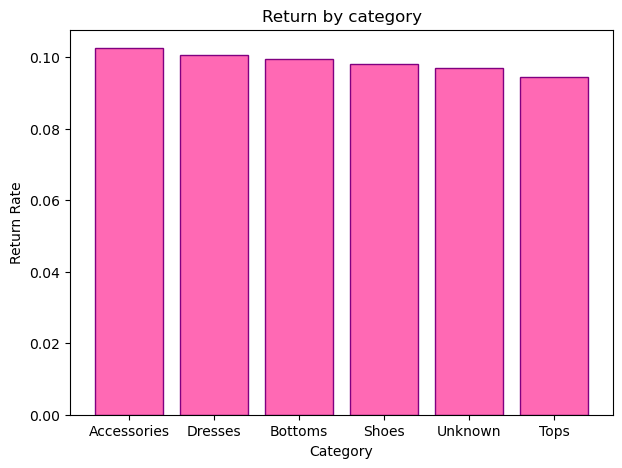

In [41]:
plt.figure(figsize=(7,5))
plt.bar(category_return['category'],category_return['return_rate'],color='hotpink',edgecolor='purple')
# plt.bar(category_return['category'],(1 - category_return['return_rate']), bottom=category_return['return_rate'],color='lightblue',edgecolor='yellow')
plt.xlabel('Category')
plt.ylabel('Return Rate')
plt.title('Return by category')
plt.show()

### Discount and Return probability

In [42]:
df['discount_rate']=pd.cut(df['discount'],bins=[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,1],labels=['0-10%','10-20%','20-30%','30-40%','40-50%','50-60%','60-70%','70%+'])
disc_return = (
    df.groupby(['category','discount_rate'])
      .agg({
          'revenue':'sum',
          'returned':'mean'
      })
      .sort_values(by='returned', ascending=False)
      .reset_index()
)
disc_return.head()

/var/folders/y8/4rjnjsgj50qcw4k1myyp4j3r0000gn/T/ipykernel_2784/3281518674.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['category','discount_rate'])


,category,discount_rate,revenue,returned
0,Unknown,10-20%,8477.944,0.125000
1,Shoes,10-20%,202520.760,0.122449
2,Bottoms,0-10%,443490.012,0.110818
3,Shoes,20-30%,95037.992,0.105364
4,Shoes,0-10%,467431.794,0.104209


In [43]:
disc_return = disc_return[disc_return['revenue'] > 0]
disc_return

,category,discount_rate,revenue,returned
0,Unknown,10-20%,8477.944,0.125000
1,Shoes,10-20%,202520.760,0.122449
2,Bottoms,0-10%,443490.012,0.110818
3,Shoes,20-30%,95037.992,0.105364
4,Shoes,0-10%,467431.794,0.104209
5,Dresses,0-10%,448369.677,0.098772
6,Accessories,0-10%,443395.323,0.098517
7,Accessories,10-20%,194930.224,0.097895
8,Unknown,0-10%,17475.615,0.096386
9,Tops,0-10%,436946.967,0.096360


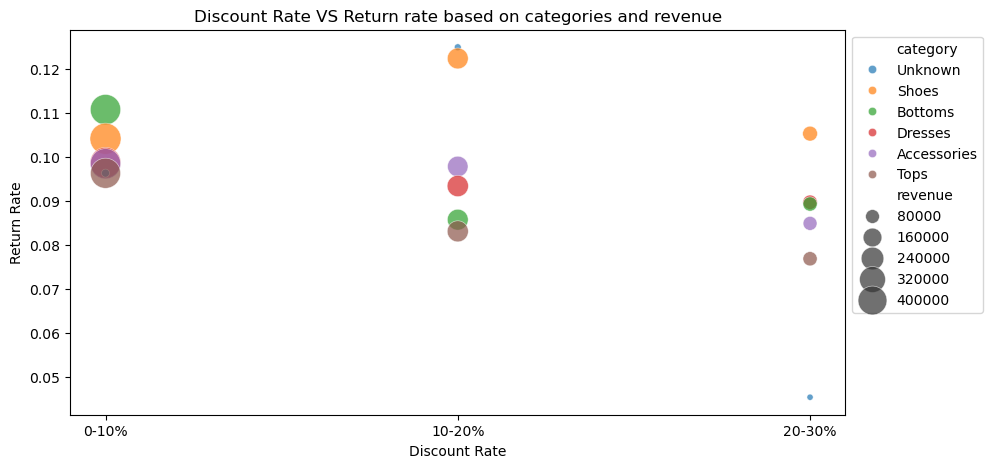

In [44]:
import seaborn as sns
plt.figure(figsize=(10,5))
ax = sns.scatterplot(
    data=disc_return,
    x='discount_rate',
    y='returned',
    size='revenue',
    hue='category',
    sizes=(20, 500),    # marker size range
    alpha=0.7
)
sns.move_legend(ax,"upper left",bbox_to_anchor=(1,1))
plt.title('Discount Rate VS Return rate based on categories and revenue')
plt.xlabel('Discount Rate')
plt.ylabel('Return Rate')
plt.show()

In [45]:
# # Pivot for heatmap
# heatmap_data = disc_return.pivot(index='category', columns='discount_rate', values='returned')

# plt.figure(figsize=(10,6))
# sns.heatmap(
#     heatmap_data,
#     annot=True,       # show numbers
#     fmt=".1%",        # format as percentage
#     cmap="Reds",      # color intensity = higher return
#     linewidths=0.5
# )
# plt.title("Return Rate by Category and Discount")
# plt.ylabel("Category")
# plt.xlabel("Discount Rate")
# plt.show()

~ Insights
️1. Category vs Return Insights
- Accessories: Highest overall return rate but still generate substantial revenue, so not all returns are bad—these are valuable products.
- Dresses, Shoes, Bottoms: Moderate return rates, with some bins showing high revenue; important to monitor.
- Unknown: Very small revenue, can mostly be ignored in strategic decisions.
2. Discount Bin Observations
- 0–10%: Highest revenue overall, medium return rate → sweet spot, safe for both revenue and returns.
- 10–20%: Mixed outcomes; some categories have high return rates with medium revenue, some low return with high revenue → careful targeting needed.
- 20–30%: Lower revenue and lower return rate → discounts may be hurting profitability without generating enough volume.
3. BA Takeaways
Focus on 0–10% discount bins for high-revenue categories, maintain quality to control returns.
Monitor 10–20% discount bins, especially for Accessories & Shoes, to avoid high-return scenarios.
20–30% discounts may not be worthwhile—low revenue, not enough uplift, still some returns.

# Final Insights:
1. Seasonality
- Revenue shows recurring peaks during May–July, while Winter contributes the highest overall revenue, indicating both short-term demand spikes and strong seasonal performance.

2. Revenue vs Profit Efficiency
- Accessories generate the highest revenue, while Dresses deliver the highest profit, highlighting differences in category-level profitability and margin efficiency.

3. Store Efficiency

- Store size does not correlate with revenue; smaller stores generate higher revenue per square meter, indicating better operational efficiency.

4. Customer Retention

- Repeat customers contribute the majority of revenue and profit (~85%), indicating strong reliance on customer loyalty for business performance.

In [63]:
# Category mix
# all categories are performing basically same
porto_cat = (
    df.where(df['store_id']=='S002')
    .groupby('category')['revenue']
    .sum()
    .reset_index(name='revenue')
      # .sort_values(by='return_rate', ascending=False)
)
porto_cat
porto_cat['rev_pct']=(porto_cat['revenue']/porto_cat['revenue'].sum())*100
porto_cat

,category,revenue,rev_pct
0,Accessories,488409.587,20.769142
1,Bottoms,439304.519,18.680997
2,Dresses,453931.692,19.303003
3,Shoes,490410.364,20.854223
4,Tops,460425.468,19.579145
5,Unknown,19130.125,0.813490


In [68]:
# Discount behaviour
# discount is same across stores
avg_discount = (
    df.groupby('store_name')['discount']
    .mean()
    .reset_index(name='discount')
)
avg_discount

,store_name,discount
0,Coimbra Boutique,0.055675
1,Faro Outlet,0.054665
2,Lisbon Flagship,0.054958
3,Online,0.056490
4,Porto Center,0.054664


In [75]:
# Discount behaviour
avg_discount = (
    df.groupby('store_name')
    .agg({
        'revenue':'sum',
        'discount':'mean',
        'profit':'sum'
    })
)
avg_discount

,revenue,discount,profit
store_name,,,
Coimbra Boutique,2369401.989,0.055675,1492263.41
Faro Outlet,2418159.025,0.054665,1529947.03
Lisbon Flagship,2413181.997,0.054958,1517896.28
Online,2349876.776,0.056490,1488467.07
Porto Center,2351611.755,0.054664,1477858.59


In [76]:
# Discount behaviour
# discount is almost same so that's not the issue. Issue is the 3 lowest performing categories - accessories, bottoms, tops
avg_dis_cat = (
    df.groupby(['store_name','category'])
    .agg({
        'revenue':'sum',
        'discount':'mean',
        'profit':'sum'
    })
)
avg_dis_cat

revenue  discount     profit
store_name       category                                    
Coimbra Boutique Accessories  469715.983  0.053055  292169.28
                 Bottoms      463973.178  0.055414  289485.59
                 Dresses      475708.215  0.056147  302599.54
                 Shoes        483581.309  0.055708  304339.69
                 Tops         460038.254  0.058275  294607.71
                 Unknown       16385.050  0.052239    9061.60
Faro Outlet      Accessories  482121.635  0.051928  299518.05
                 Bottoms      480842.687  0.057809  306690.85
                 Dresses      488009.075  0.051964  310600.14
                 Shoes        462205.419  0.056754  292071.85
                 Tops         478943.132  0.055437  305780.84
                 Unknown       26037.077  0.045714   15285.30
Lisbon Flagship  Accessories  470425.108  0.053638  294631.86
                 Bottoms      472106.104  0.053646  297438.40
                 Dresses      479816.637  0.058295  304699.57
                 Shoes        494254.283  0.053893  309872.18
                 Tops         475002.209  0.055385  298903.20
                 Unknown       21577.656  0.052809   12351.07
Online           Accessories  470807.940  0.057597  300707.17
                 Bottoms      469039.488  0.054795  296721.13
                 Dresses      474185.782  0.055130  302090.99
                 Shoes        449918.251  0.059890  284964.00
                 Tops         461078.036  0.055798  289490.95
                 Unknown       24847.279  0.044554   14492.83
Porto Center     Accessories  488409.587  0.053504  308705.14
                 Bottoms      439304.519  0.052757  276465.56
                 Dresses      453931.692  0.054743  288743.13
                 Shoes        490410.364  0.057803  307919.07
                 Tops         460425.468  0.053900  284762.66
                 Unknown       19130.125  0.066667   11263.03

Porto Center underperforms despite comparable discount rates and store size efficiency, indicating that weaker performance in categories like Bottoms, Dresses, and Tops—rather than pricing strategy—is the primary driver of lower overall revenue.